In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("E:/New folder/predictive-maintenance-system/data/ai4i2020_cleaned.csv")

Machine Failure 

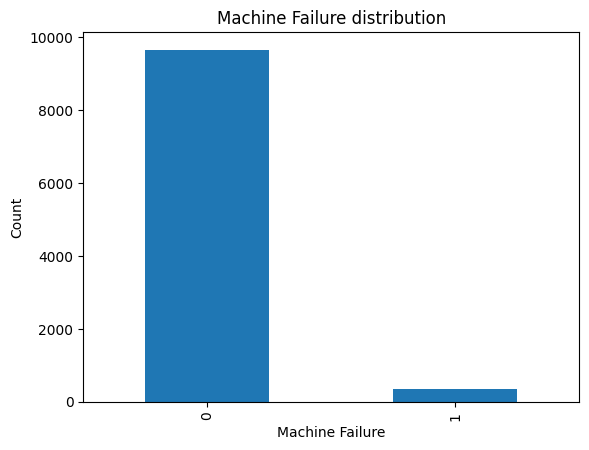

In [3]:
df["Machine failure"].value_counts().plot(kind="bar")

plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.title("Machine Failure distribution")
plt.show()


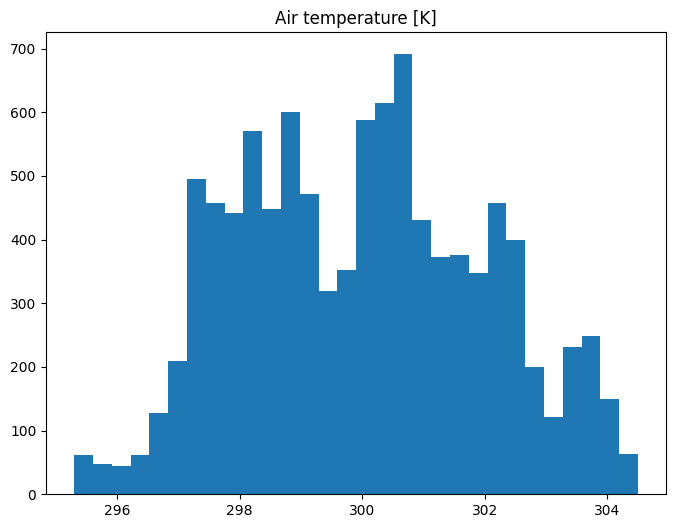

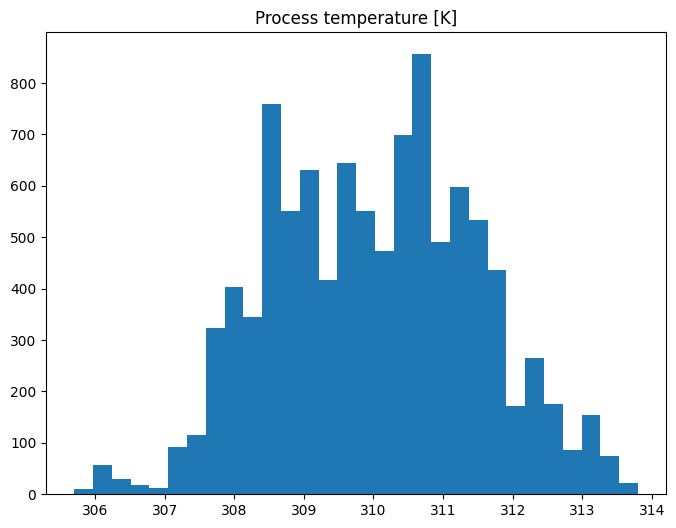

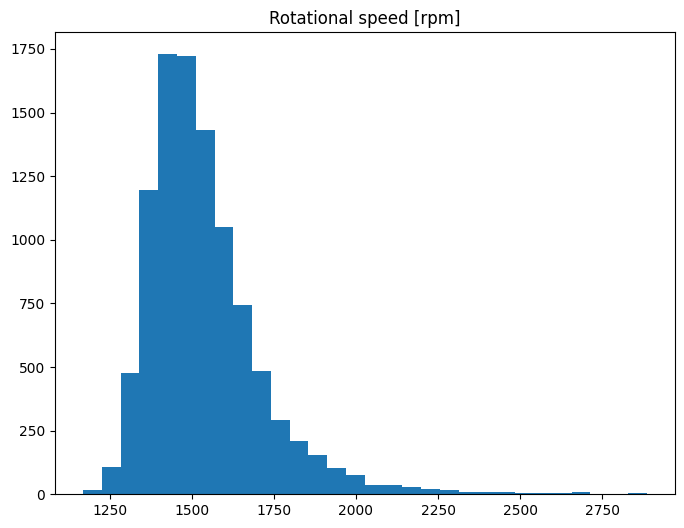

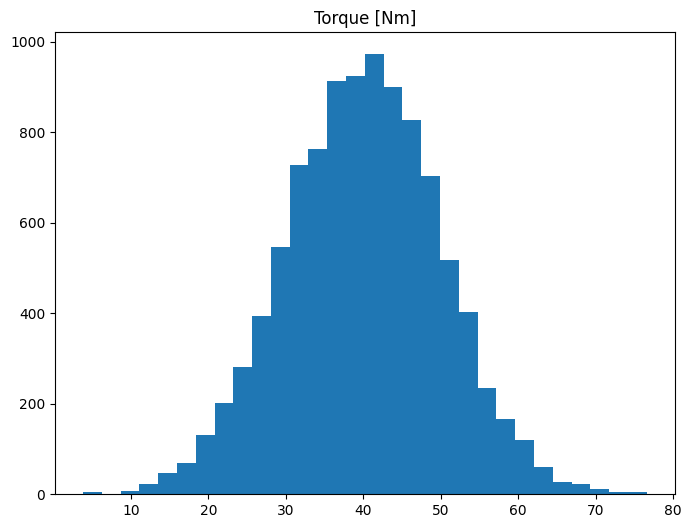

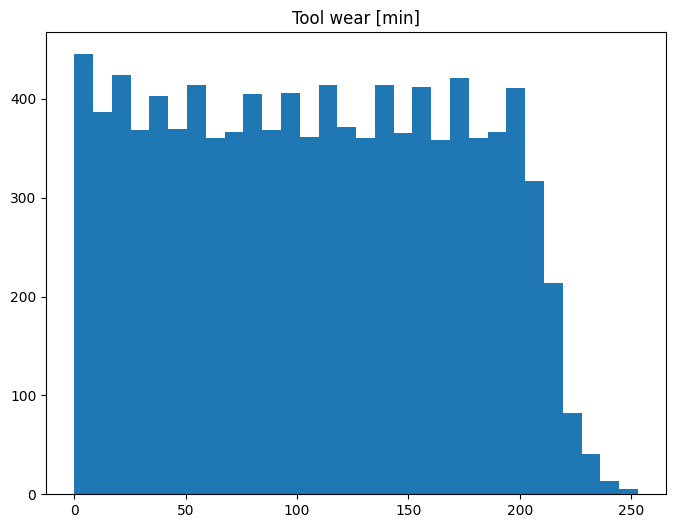

In [4]:
numerical_columns=[
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
for column in numerical_columns:
    plt.figure(figsize=(8,6))
    plt.hist(df[column],bins=30)
    plt.title(column)
    plt.show()

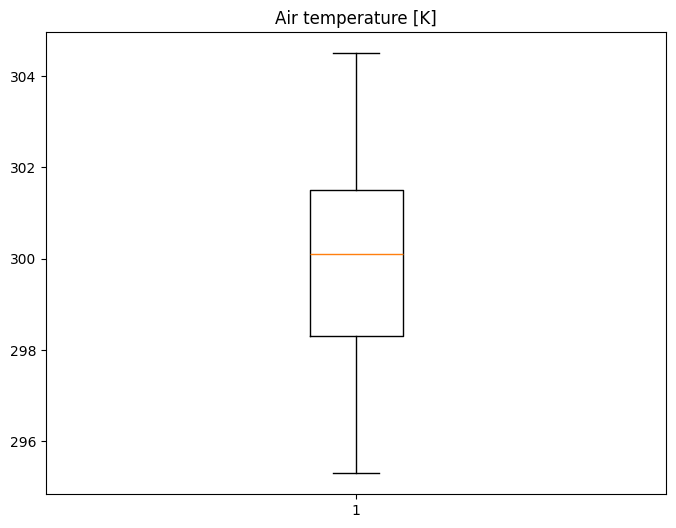

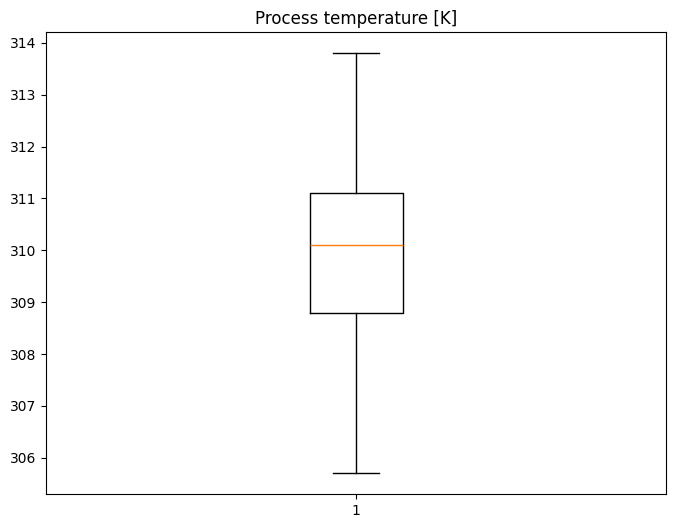

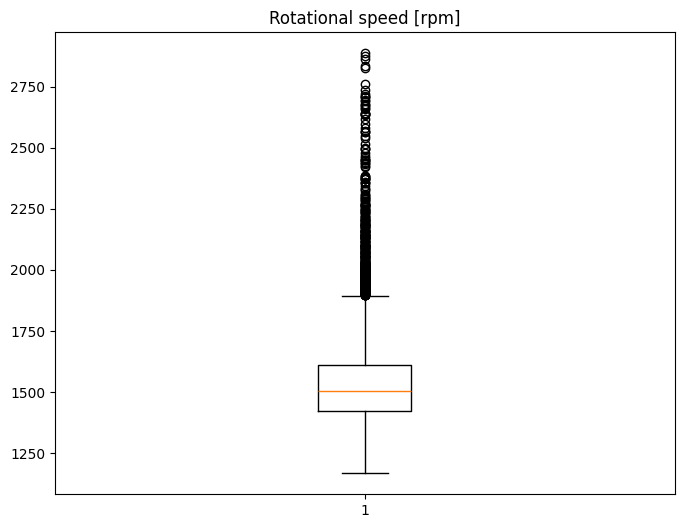

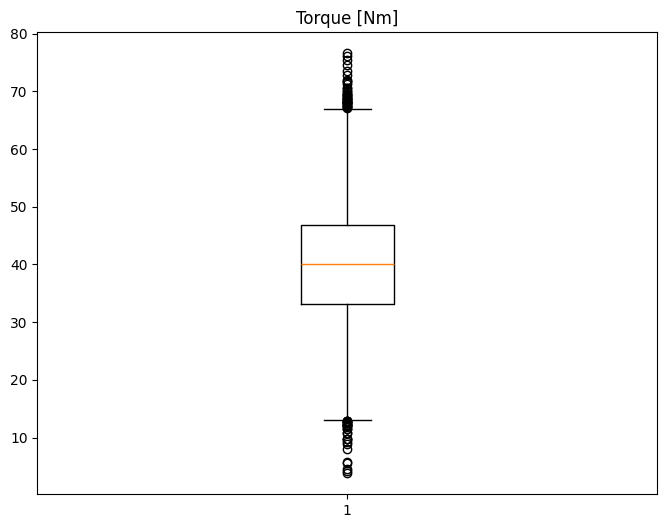

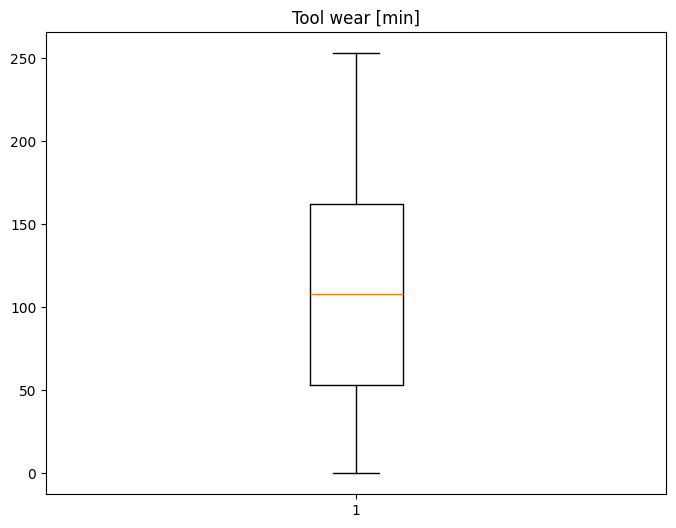

In [6]:
for column in numerical_columns:
    plt.figure(figsize=(8,6))
    plt.boxplot(df[column])
    plt.title(column)
    plt.show()

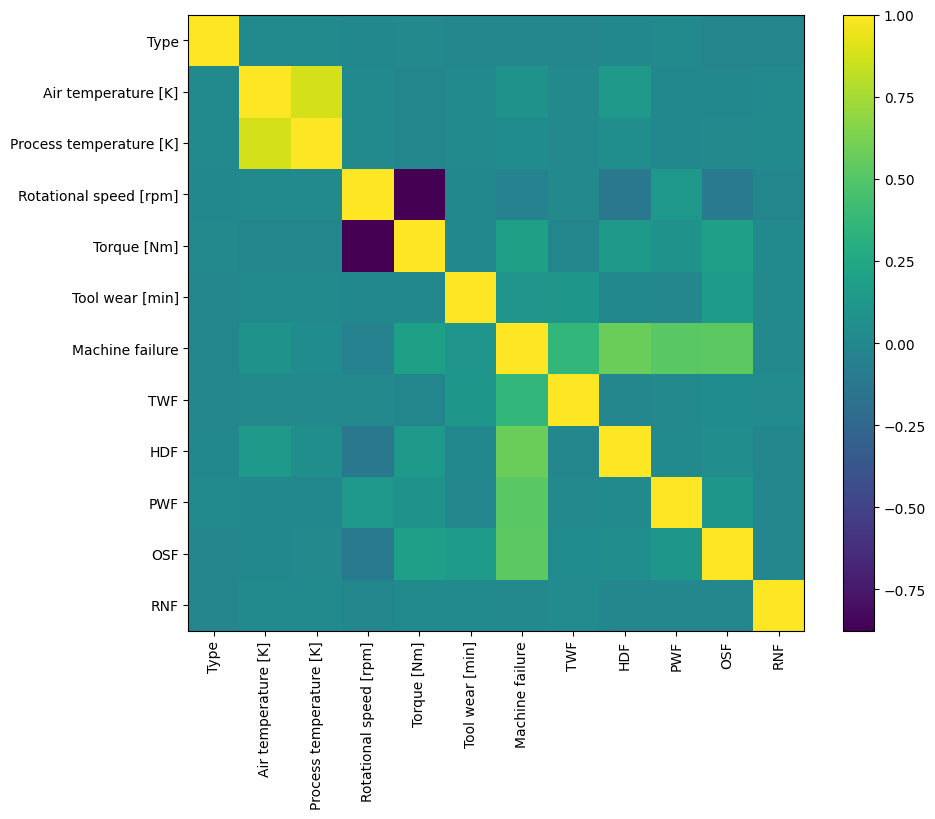

In [7]:
correlation=df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(correlation)
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)
plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)
plt.colorbar()
plt.show()



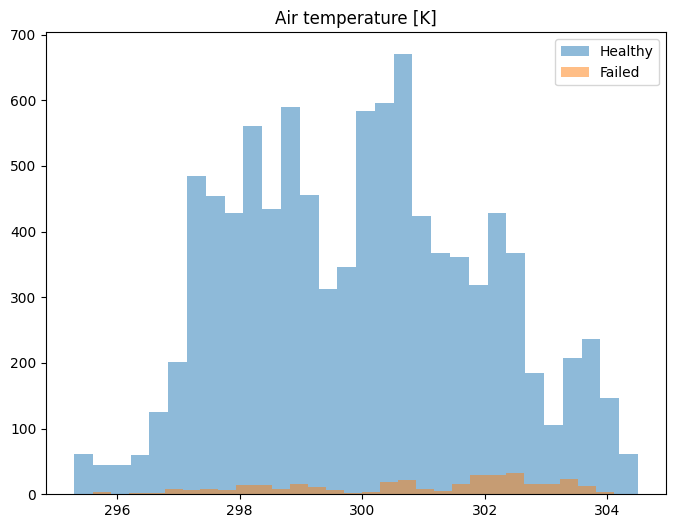

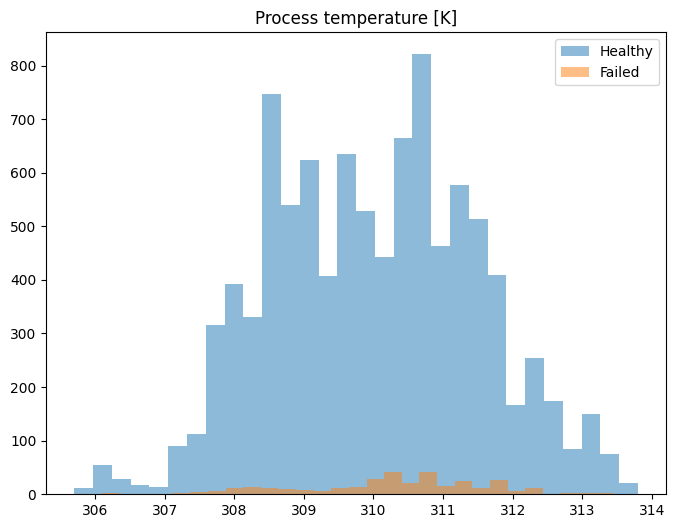

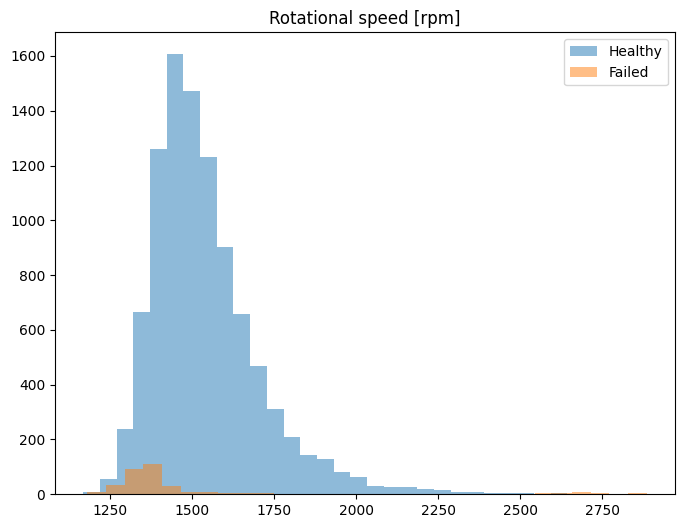

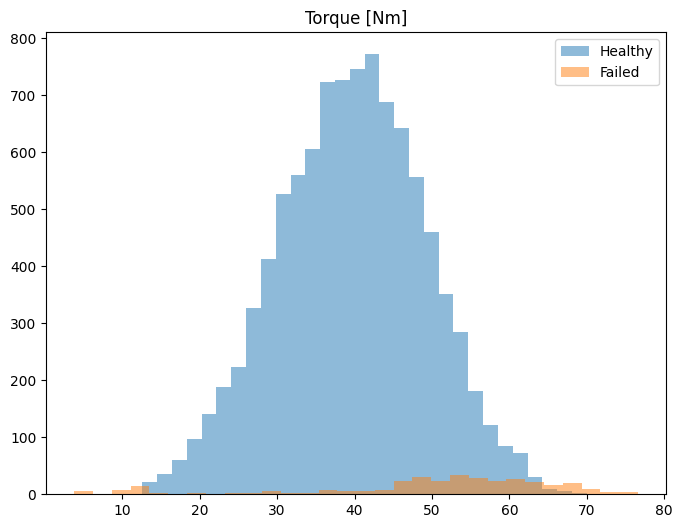

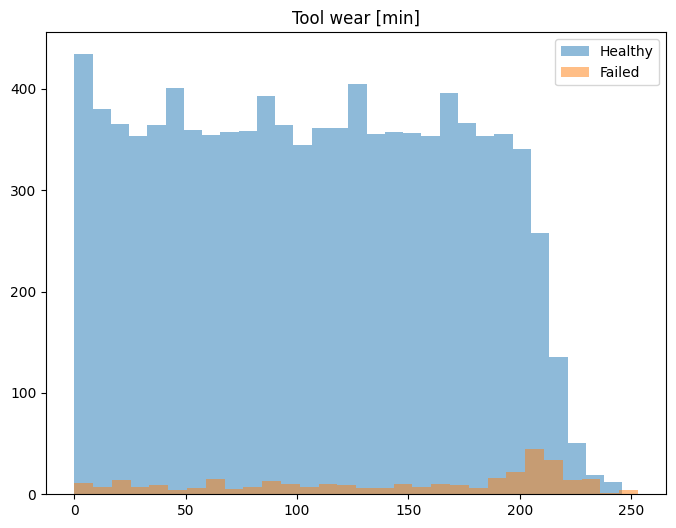

In [10]:
failed=df[df["Machine failure"]==1]
healthy=df[df["Machine failure"]==0]
for column in numerical_columns:
    plt.figure(figsize=(8,6))
    plt.hist(healthy[column],bins=30,alpha=0.5,label="Healthy")
    plt.hist(failed[column],bins=30,alpha=0.5,label="Failed")
    plt.title(column)
    plt.legend()
    plt.show()
    

In [11]:
correlation["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
Type                      -0.005152
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

Feature Engineering


In [12]:
df["Temperature Difference"]=(
    df["Process temperature [K]"]-df["Air temperature [K]"]
)

In [13]:
df["Wear Torque Ratio"]=(
    df["Tool wear [min]"]/(df["Tool wear [min]"]+1)
)

In [14]:
df["Machanical Stress"]=(
    df["Torque [Nm]"]*df["Rotational speed [rpm]"]
)

In [15]:
df["Thermal Stress"]=(
    df["Process temperature [K]"]*df["Air temperature [K]"]
)

In [16]:
prod_df=df.drop(
    columns=["TWF","HDF","PWF","OSF","RNF"]
)

In [17]:
prod_df.to_csv("E:/New folder/predictive-maintenance-system/data/engineered_data.csv",index=False)